# US Traffic Accident Severity & Risk Modeling

**Course:** CSGY-6513 Big Data, Section C  
**Semester:** Spring 2026  
**Instructor:** Prof. Amit Patel  

## Team Members
- Ananya Nadig (an4968)  
- Isha Jariwala (ij2221)  
- Rhea Shastri (rs9459)


In [ ]:
import os, json

# Kaggle account credentials - used to authenticate and download datasets via Kaggle API
kaggle_username = "YOUR_KAGGLE_USERNAME"
kaggle_key = "YOUR_KAGGLE_API_TOKEN"

# Create the .kaggle directory in the home folder if it doesn't already exist
# This is the default location where Kaggle looks for credentials
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

# Write the Kaggle credentials into a JSON file called kaggle.json
# Kaggle API requires this file to authenticate API requests
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": kaggle_username, "key": kaggle_key}, f)

# Set file permissions to owner-read/write only (600)
# This is required by Kaggle API for security - it will throw a warning if permissions are too open
os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)

# Confirm that the credentials file has been successfully created
print("kaggle.json created")

kaggle.json created


In [ ]:
!pip install kaggle

In [ ]:
!find ~/.local -name kaggle -type f 2>/dev/null

In [ ]:
#!~/.local/bin/kaggle datasets download -d sobhanmoosavi/us-accidents

In [ ]:
!kaggle datasets download -d sobhanmoosavi/us-accidents

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
us-accidents.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
import zipfile  # Built-in Python library for handling ZIP files

# Open the downloaded Kaggle dataset ZIP file in read mode
# "us-accidents.zip" is the file downloaded from Kaggle in the previous step
with zipfile.ZipFile("us-accidents.zip", "r") as zip_ref:

    # Extract all contents of the ZIP file into the current directory (".")
    # This will produce the raw CSV file: US_Accidents_March23.csv
    zip_ref.extractall(".")

In [ ]:
!ls -lh

total 3.5G
drwxr-xr-x 2 root root  44K May  6 20:58 cleaned_accidents
drwxr-xr-x 1 root root 4.0K Apr 16 13:28 sample_data
-rw-r--r-- 1 root root 2.9G May  6 21:03 US_Accidents_March23.csv
-rw-r--r-- 1 root root 654M May 28  2023 us-accidents.zip


In [ ]:
from pyspark.sql import SparkSession  # Main entry point for all PySpark functionality

# Create a Spark session or get an existing one if already running
# SparkSession is required to use any PySpark operations
# getOrCreate() reuses existing session instead of creating a duplicate
spark = SparkSession.builder.getOrCreate()

# Load the extracted CSV file into a PySpark DataFrame
# header=True  → treats the first row as column names
# inferSchema=True → automatically detects data types for each column
#                    (e.g. integers, strings, doubles) instead of reading everything as string
df = spark.read.csv("US_Accidents_March23.csv", header=True, inferSchema=True)

# Count and print the total number of rows in the dataset
# This confirms the data loaded correctly and shows the scale of the dataset
print(df.count())

# Print the schema of the DataFrame
# Shows all column names and their detected data types
# Useful to verify inferSchema worked correctly
df.printSchema()

# Display the first 5 rows of the DataFrame
# Quick sanity check to visually inspect the raw data
df.show(5)

7728394
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- End_Time: timestamp (nullable = true)
 |-- Start_Lat: double (nullable = true)
 |-- Start_Lng: double (nullable = true)
 |-- End_Lat: double (nullable = true)
 |-- End_Lng: double (nullable = true)
 |-- Distance(mi): double (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: timestamp (nullable = true)
 |-- Temperature(F): double (nullable = true)
 |-- Wind_Chill(F): double (nullable = true)
 |-- Humidity(%): double (nullable = true)
 |-- Pressure(in): double (nullable = true

## Selecting the columns

In [ ]:
cols = [
 "Severity",
 "Start_Time",
 "State",
 "Temperature(F)",
 "Visibility(mi)",
 "Wind_Speed(mph)",
 "Weather_Condition",
 "Sunrise_Sunset",
 "Junction",
 "Traffic_Signal",
 "Pressure(in)"
]

# Select required columns
df_small = df.select(*cols)

# Rename columns for easier processing
df_small = df_small.withColumnRenamed("Temperature(F)", "Temperature") \
                   .withColumnRenamed("Visibility(mi)", "Visibility") \
                   .withColumnRenamed("Wind_Speed(mph)", "Wind_Speed")

df_small = df_small.withColumnRenamed("Pressure(in)", "Pressure")

# Verify
df_small.printSchema()
df_small.show(5)

root
 |-- Severity: integer (nullable = true)
 |-- Start_Time: timestamp (nullable = true)
 |-- State: string (nullable = true)
 |-- Temperature: double (nullable = true)
 |-- Visibility: double (nullable = true)
 |-- Wind_Speed: double (nullable = true)
 |-- Weather_Condition: string (nullable = true)
 |-- Sunrise_Sunset: string (nullable = true)
 |-- Junction: boolean (nullable = true)
 |-- Traffic_Signal: boolean (nullable = true)
 |-- Pressure: double (nullable = true)

+--------+-------------------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+
|Severity|         Start_Time|State|Temperature|Visibility|Wind_Speed|Weather_Condition|Sunrise_Sunset|Junction|Traffic_Signal|Pressure|
+--------+-------------------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+
|       3|2016-02-08 05:46:00|   OH|       36.9|      10.0|      NULL|       Light Rain|         Night|   fals

## Handle Missing Values

In [ ]:
from pyspark.sql.functions import col, sum as spark_sum

# Step 1: Check missing values
df_small.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df_small.columns
]).show()

# Remove duplicates FIRST
df_small = df_small.dropDuplicates()

# Drop critical nulls
df_small = df_small.dropna(subset=[
    "Temperature",
    "Visibility",
    "Start_Time"
])

median_pressure = df_small.approxQuantile("Pressure", [0.5], 0.01)[0]
df_small = df_small.fillna({"Pressure": median_pressure})

# Fill remaining nulls
df_small = df_small.fillna({
    "Wind_Speed": 0,
    "Weather_Condition": "Unknown",
    "Sunrise_Sunset": "Unknown",
    "Pressure": median_pressure
})


# Remove invalid rows
df_small = df_small.filter(col("Sunrise_Sunset") != "Unknown")

# Verify after cleaning
df_small.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df_small.columns
]).show()


+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+
|Severity|Start_Time|State|Temperature|Visibility|Wind_Speed|Weather_Condition|Sunrise_Sunset|Junction|Traffic_Signal|Pressure|
+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+
|       0|         0|    0|     163853|    177098|    571233|           173459|         23246|       0|             0|  140679|
+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+

+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+
|Severity|Start_Time|State|Temperature|Visibility|Wind_Speed|Weather_Condition|Sunrise_Sunset|Junction|Traffic_Signal|Pressure|
+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+

## Feature Engineering

In [ ]:
from pyspark.sql.functions import hour, when, col

# Extract hour from timestamp
df_small = df_small.withColumn("Hour", hour("Start_Time"))

# Create binary severity label (1 = high severity, 0 = low)
df_small = df_small.withColumn(
    "label",
    when(col("Severity") >= 3, 1).otherwise(0)
)

# Create rush hour feature
df_small = df_small.withColumn(
    "is_rush_hour",
    when((col("Hour").between(7, 9)) | (col("Hour").between(16, 18)), 1).otherwise(0)
)

# Verify
df_small.select("Start_Time", "Hour", "label", "is_rush_hour").show(5)

+-------------------+----+-----+------------+
|         Start_Time|Hour|label|is_rush_hour|
+-------------------+----+-----+------------+
|2016-02-16 07:52:41|   7|    1|           1|
|2016-02-19 06:08:10|   6|    0|           0|
|2016-03-03 09:42:54|   9|    1|           1|
|2016-03-04 08:14:01|   8|    0|           1|
|2016-03-18 10:55:02|  10|    0|           0|
+-------------------+----+-----+------------+
only showing top 5 rows


## Sample dataset

In [ ]:
# =========================
# Sampling
# =========================
df_sample = df_small.sample(fraction=0.2, seed=42)
df_sample = df_sample.cache()
print("Sample size:", df_sample.count())

# =========================
# Feature Engineering
# =========================
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import dayofweek, when, col
from pyspark.sql.functions import lower



# Day/Night encoding
sun_indexer = StringIndexer(
    inputCol="Sunrise_Sunset",
    outputCol="sun_idx",
    handleInvalid="keep"
)

sun_model = sun_indexer.fit(df_sample)
df_sample = sun_model.transform(df_sample)

# Time features
df_sample = df_sample.withColumn("DayOfWeek", dayofweek("Start_Time"))

df_sample = df_sample.withColumn(
    "is_weekend",
    when(col("DayOfWeek").isin([1,7]), 1).otherwise(0)
)

# Add is_snow
df_sample = df_sample.withColumn(
    "is_snow",
    when(lower(col("Weather_Condition")).contains("snow"), 1).otherwise(0)
)

# Convert boolean → numeric
df_sample = df_sample.withColumn("Junction", col("Junction").cast("int"))
df_sample = df_sample.withColumn("Traffic_Signal", col("Traffic_Signal").cast("int"))

# Interaction feature
df_sample = df_sample.withColumn(
    "temp_visibility_interaction",
    col("Temperature") * col("Visibility")
)

# Low visibility risk
df_sample = df_sample.withColumn(
    "low_visibility",
    when(col("Visibility") < 5, 1).otherwise(0)
)

# Rain indicator
df_sample = df_sample.withColumn(
    "is_rain",
    when(lower(col("Weather_Condition")).contains("rain"), 1).otherwise(0)
)

#Fog indicator
df_sample = df_sample.withColumn(
    "is_fog",
    when(lower(col("Weather_Condition")).contains("fog"), 1).otherwise(0)
)

Sample size: 1307349


## Save cleaned data

In [ ]:
# Save cleaned DataFrame to Parquet format for faster read/write performance
df_sample.write.mode("overwrite").parquet("./cleaned_accidents")

# Reload the saved Parquet file and cache it in memory for faster access
df_sample = spark.read.parquet("./cleaned_accidents").cache()

# Trigger the cache and confirm total number of records loaded
df_sample.count()

1307349

The cleaned and sampled dataset is saved in Parquet format and reloaded for downstream analysis. This avoids repeatedly processing the raw CSV file and improves Spark read performance.

## Exploratory Data Analysis (EDA)

This section explores patterns in the cleaned dataset to understand factors affecting accident severity. Key aspects such as time, weather, location, and traffic conditions are analyzed.

### 1. Distribution of Accident Severity

This analysis shows how accidents are distributed across different severity levels.

In [ ]:
# Count and display the number of accidents for each severity level in ascending order
df_sample.groupBy("Severity").count().orderBy("Severity").show()

+--------+-------+
|Severity|  count|
+--------+-------+
|       1|  12291|
|       2|1014683|
|       3| 249128|
|       4|  31247|
+--------+-------+



In [ ]:
# Count and display the number of accidents for each binary label (0 = low severity, 1 = high severity)
df_sample.groupBy("label").count().show()

+-----+-------+
|label|  count|
+-----+-------+
|    1| 280375|
|    0|1026974|
+-----+-------+



**Observation:**  
The binary classification dataset is imbalanced, with low severity accidents (label = 0) significantly outnumbering high severity accidents (label = 1). This imbalance may bias the model toward predicting the majority class, and appropriate evaluation metrics such as AUC or precision-recall should be considered.

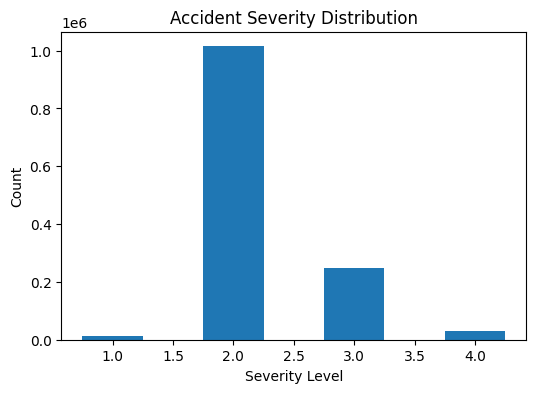

In [ ]:
# Convert severity counts from Spark DataFrame to Pandas for plotting
severity_pd = df_sample.groupBy("Severity").count().orderBy("Severity").toPandas()

import matplotlib.pyplot as plt  # Import plotting library

plt.figure(figsize=(6,4))  # Set the figure size
plt.bar(severity_pd["Severity"], severity_pd["count"], width=0.5)  # Plot bar chart of severity counts
plt.title("Accident Severity Distribution")  # Set chart title
plt.xlabel("Severity Level")  # Label x-axis
plt.ylabel("Count")  # Label y-axis
plt.show()  # Display the chart

###Severity Distribution

The distribution of accident severity is highly imbalanced, with lower severity levels occurring significantly more frequently than higher severity cases. This imbalance motivates the use of techniques such as downsampling and class weighting in predictive modeling.



### 2. Accidents by Hour of the Day

This analysis examines how accidents are distributed across different hours of the day to identify peak traffic periods.

In [ ]:
# Count and display the number of accidents for each hour of the day in ascending order
df_sample.groupBy("Hour") \
         .count() \
         .orderBy("Hour") \
         .show()

+----+------+
|Hour| count|
+----+------+
|   0| 17588|
|   1| 15132|
|   2| 14627|
|   3| 13082|
|   4| 27031|
|   5| 37921|
|   6| 70424|
|   7|104314|
|   8|103683|
|   9| 63605|
|  10| 59840|
|  11| 61489|
|  12| 58763|
|  13| 64850|
|  14| 72561|
|  15| 86416|
|  16| 97398|
|  17| 97352|
|  18| 74063|
|  19| 50841|
+----+------+
only showing top 20 rows


**Observation:**  
Accident frequency is lowest during late night and early morning hours (0–4 AM), and increases significantly during morning commuting hours, peaking around 7–8 AM. A second peak is observed in the late afternoon (4–5 PM), corresponding to evening rush hours. This pattern indicates that traffic congestion during daily commute times contributes to higher accident occurrence.

### 3. Accidents by Time of Day (Day vs Night)

This analysis compares accident frequency during daytime and nighttime conditions using the Sunrise_Sunset feature.

In [ ]:
# Count and display the number of accidents during day and night conditions
df_sample.groupBy("Sunrise_Sunset").count().show()

+--------------+------+
|Sunrise_Sunset| count|
+--------------+------+
|         Night|393619|
|           Day|913730|
+--------------+------+



**Observation:**  
A significantly higher number of accidents occur during the daytime compared to nighttime, with more than twice as many incidents recorded during the day. This is likely due to increased traffic volume and activity during daytime hours, although nighttime conditions may still pose higher risks due to reduced visibility.

### 4. Impact of Weather Conditions

This analysis examines how different weather conditions affect accident frequency.

In [ ]:
# Count and display the top 10 weather conditions by accident frequency in descending order
df_sample.groupBy("Weather_Condition") \
         .count() \
         .orderBy("count", ascending=False) \
         .show(10)

+-----------------+------+
|Weather_Condition| count|
+-----------------+------+
|             Fair|416902|
|    Mostly Cloudy|177342|
|            Clear|157784|
|           Cloudy|135431|
|    Partly Cloudy|122578|
|         Overcast| 74414|
|       Light Rain| 61977|
| Scattered Clouds| 39780|
|       Light Snow| 20732|
|              Fog| 16543|
+-----------------+------+
only showing top 10 rows


**Observation:**  
Most accidents occur under normal weather conditions such as fair, clear, and cloudy skies. This is likely because these conditions are more frequent, leading to higher overall accident counts. Adverse weather conditions like rain, snow, and fog have fewer total accidents, but they may still increase the risk of accidents relative to their occurrence.

### 5. Impact of Road Features

This analysis examines how road features such as junctions and traffic signals influence accident occurrence.

In [ ]:
# Count and display the number of accidents at junction vs non-junction locations
df_sample.groupBy("Junction").count().show()

# Count and display the number of accidents at traffic signal vs non-traffic signal locations
df_sample.groupBy("Traffic_Signal").count().show()

+--------+-------+
|Junction|  count|
+--------+-------+
|       1| 102758|
|       0|1204591|
+--------+-------+

+--------------+-------+
|Traffic_Signal|  count|
+--------------+-------+
|             1| 209751|
|             0|1097598|
+--------------+-------+



**Observation (Junction):**  
Most accidents occur on non-junction roads, as indicated by the significantly higher count when Junction = false. This is likely because non-junction road segments are more common. However, junctions may still present higher risk due to complex traffic interactions.

**Observation (Traffic Signal):**  
Most accidents occur in areas without traffic signals, as indicated by the higher count when Traffic_Signal = false. This is likely because a large portion of road segments do not have traffic signals. However, intersections with signals may still involve complex traffic interactions that influence accident risk.

### 6. Predicting Accident Severity

In this section, machine learning models are used to predict accident severity based on features such as time, weather, and road conditions.

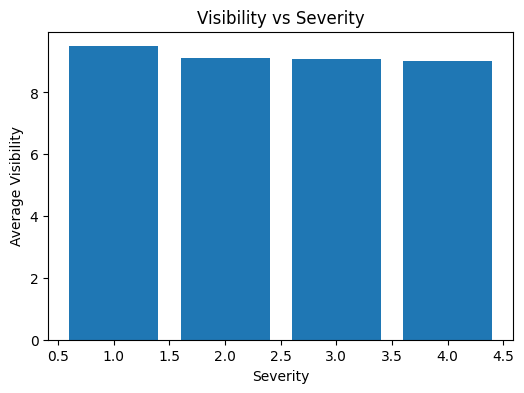

In [ ]:
# Step 1: create dataframe
vis_severity = df_sample.groupBy("Severity") \
    .avg("Visibility") \
    .orderBy("Severity") \
    .toPandas()

# Step 2: plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(vis_severity["Severity"], vis_severity["avg(Visibility)"])

plt.xlabel("Severity")
plt.ylabel("Average Visibility")
plt.title("Visibility vs Severity")

plt.show()

###7. Target Variable Analysis
This shows how many accidents belong to each severity level. It helps identify class imbalance, which is important before building the machine learning model.

In [ ]:
# Count and display the number of accidents for each severity level in ascending order
df_sample.groupBy("Severity").count().orderBy("Severity").show()

+--------+-------+
|Severity|  count|
+--------+-------+
|       1|  12291|
|       2|1014683|
|       3| 249128|
|       4|  31247|
+--------+-------+



###8. Time-Based Analysis

This analyzes accident patterns by hour, month, year, and day/night. It helps identify when accidents happen most frequently.

In [ ]:
from pyspark.sql.functions import hour, month, year  # Import time extraction functions

# Extract hour, month and year from the Start_Time column into separate columns
df_sample = df_sample.withColumn("Hour", hour("Start_Time"))
df_sample = df_sample.withColumn("Month", month("Start_Time"))
df_sample = df_sample.withColumn("Year", year("Start_Time"))

# Count and display number of accidents for each hour of the day
df_sample.groupBy("Hour").count().orderBy("Hour").show()

# Count and display number of accidents for each month of the year
df_sample.groupBy("Month").count().orderBy("Month").show()

# Count and display number of accidents for each year in the dataset
df_sample.groupBy("Year").count().orderBy("Year").show()

# Count and display number of accidents during daytime vs nighttime conditions
df_sample.groupBy("Sunrise_Sunset").count().show()

+----+------+
|Hour| count|
+----+------+
|   0| 17588|
|   1| 15132|
|   2| 14627|
|   3| 13082|
|   4| 27031|
|   5| 37921|
|   6| 70424|
|   7|104314|
|   8|103683|
|   9| 63605|
|  10| 59840|
|  11| 61489|
|  12| 58763|
|  13| 64850|
|  14| 72561|
|  15| 86416|
|  16| 97398|
|  17| 97352|
|  18| 74063|
|  19| 50841|
+----+------+
only showing top 20 rows
+-----+------+
|Month| count|
+-----+------+
|    1|123639|
|    2|110115|
|    3| 95426|
|    4| 98695|
|    5| 94762|
|    6| 99673|
|    7| 89259|
|    8|106489|
|    9|112200|
|   10|116364|
|   11|124608|
|   12|136119|
+-----+------+

+----+------+
|Year| count|
+----+------+
|2016| 78233|
|2017|136440|
|2018|171428|
|2019|183051|
|2020|195134|
|2021|247799|
|2022|258886|
|2023| 36378|
+----+------+

+--------------+------+
|Sunrise_Sunset| count|
+--------------+------+
|         Night|393619|
|           Day|913730|
+--------------+------+



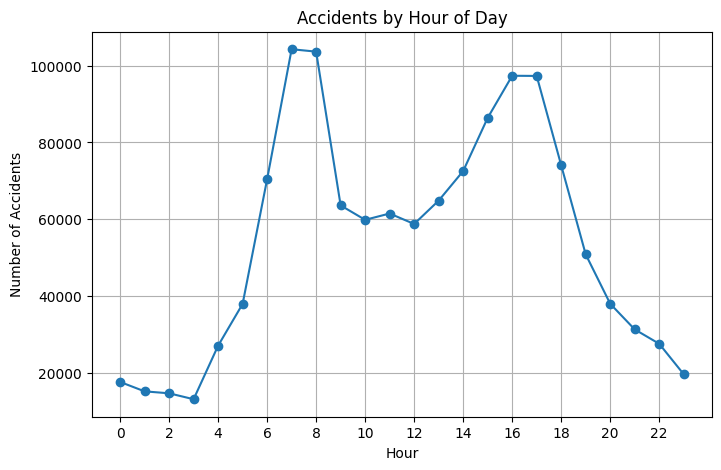

In [ ]:
# Convert hourly accident counts from Spark DataFrame to Pandas for plotting
hour_pd = df_sample.groupBy("Hour").count().orderBy("Hour").toPandas()

import matplotlib.pyplot as plt  # Import plotting library

plt.figure(figsize=(8,5))  # Set figure size
plt.plot(hour_pd["Hour"], hour_pd["count"], marker='o')  # Plot line chart with markers for each hour
plt.title("Accidents by Hour of Day")  # Set chart title
plt.xticks(range(0,24,2))  # Show x-axis ticks every 2 hours for readability
plt.xlabel("Hour")  # Label x-axis
plt.ylabel("Number of Accidents")  # Label y-axis
plt.grid(True)  # Add gridlines for easier reading
plt.show()  # Display the chart

### Hourly Accident Trends

The hourly distribution of accidents shows two prominent peaks during the day. The first peak occurs in the morning hours (around 7–9 AM), while the second peak appears in the late afternoon and evening (around 4–6 PM). These periods correspond to typical commute times when traffic volume is highest.

In contrast, accident frequency is lowest during late-night and early-morning hours, reflecting reduced traffic activity. This pattern highlights the strong relationship between traffic density and accident occurrence, suggesting that targeted safety measures during peak hours could significantly reduce accident risk.

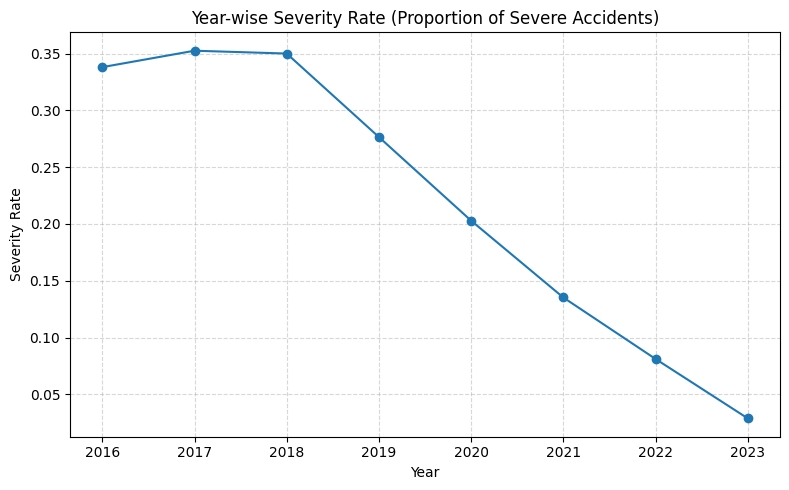

In [ ]:
from pyspark.sql.functions import avg, col  # Import aggregation and column functions
import matplotlib.pyplot as plt  # Import plotting library

# Calculate proportion of severe accidents (severity 3 or 4) per year and convert to Pandas
year_severity = df_sample.withColumn(
    "high_severity", (col("Severity") >= 3).cast("int")
).groupBy("Year") \
 .agg(avg("high_severity").alias("severity_rate")) \
 .orderBy("Year") \
 .toPandas()

plt.figure(figsize=(8,5))  # Set figure size
plt.plot(year_severity["Year"], year_severity["severity_rate"], marker='o')  # Plot year-wise severity rate
plt.title("Year-wise Severity Rate (Proportion of Severe Accidents)")  # Set chart title
plt.xlabel("Year")  # Label x-axis
plt.ylabel("Severity Rate")  # Label y-axis
plt.grid(True, linestyle='--', alpha=0.5)  # Add dashed gridlines
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()  # Display the chart

### Year-wise Severity Trend

The year-wise severity rate shows a clear declining trend in the proportion of high-severity accidents from 2016 to 2023. The severity rate remains relatively stable and high between 2016 and 2018 (around 34–35%), after which a consistent and significant decrease is observed. Starting from 2019, the severity rate drops sharply, reaching its lowest point in 2023. This indicates that while accidents may still be occurring, the proportion of severe accidents has reduced over time.

The decline after 2019 may be associated with changes in traffic patterns, improved road safety measures, or reduced mobility during and after the COVID-19 pandemic. Overall, the trend suggests a positive shift toward safer driving conditions and reduced accident severity in recent years.

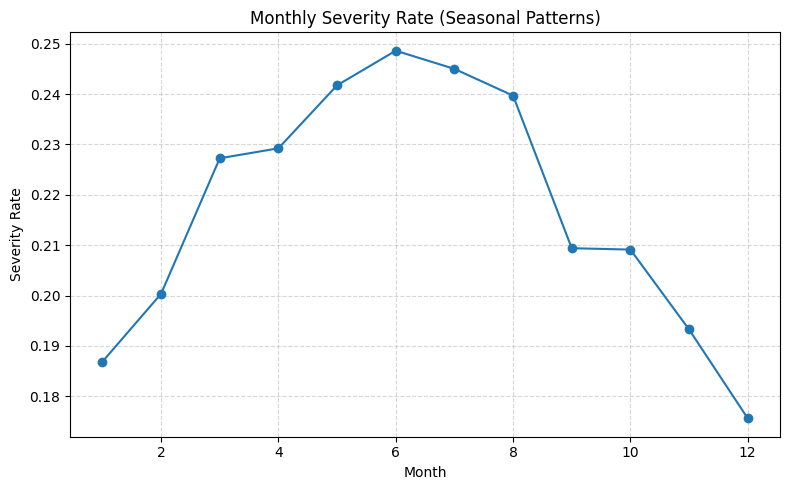

In [ ]:
# Calculate proportion of severe accidents per month and convert to Pandas for plotting
month_severity = df_sample.withColumn(
    "high_severity", (col("Severity") >= 3).cast("int")
).groupBy("Month") \
 .agg(avg("high_severity").alias("severity_rate")) \
 .orderBy("Month") \
 .toPandas()

plt.figure(figsize=(8,5))  # Set figure size
plt.plot(month_severity["Month"], month_severity["severity_rate"], marker='o')  # Plot monthly severity rate

plt.title("Monthly Severity Rate (Seasonal Patterns)")  # Set chart title
plt.xlabel("Month")  # Label x-axis
plt.ylabel("Severity Rate")  # Label y-axis

plt.grid(True, linestyle='--', alpha=0.5)  # Add dashed gridlines
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()  # Display the chart

### Monthly (Seasonal) Severity Trend

The monthly severity rate reveals a clear seasonal pattern in the proportion of high-severity accidents. The severity rate gradually increases from January and reaches its peak during late spring and early summer months (around May to July). After this peak, a steady decline is observed toward the end of the year, with the lowest severity rates occurring in November and December.

This trend suggests that accident severity is slightly higher during mid-year months, which may be influenced by factors such as increased travel, higher traffic volumes, and changing driving conditions. Conversely, the lower severity rates in winter months may reflect more cautious driving behavior, despite potentially adverse weather conditions.

Overall, while seasonal variations exist, the changes in severity rate are moderate, indicating that environmental and traffic-related factors collectively influence accident severity throughout the year.

###9. Weather and Environmental Analysis
This checks how weather and environmental conditions are distributed. Visibility, temperature, and wind speed can strongly affect accident severity.


In [ ]:
# Print all column names in the DataFrame to verify available features
print(df_sample.columns)

['Severity', 'Start_Time', 'State', 'Temperature', 'Visibility', 'Wind_Speed', 'Weather_Condition', 'Sunrise_Sunset', 'Junction', 'Traffic_Signal', 'Pressure', 'Hour', 'label', 'is_rush_hour', 'sun_idx', 'DayOfWeek', 'is_weekend', 'is_snow', 'temp_visibility_interaction', 'low_visibility', 'is_rain', 'is_fog', 'Month', 'Year']


In [ ]:
# Display top 10 weather conditions by accident count in descending order
df_sample.groupBy("Weather_Condition").count().orderBy("count", ascending=False).show(10)

# Show summary statistics (count, mean, stddev, min, max) for visibility, temperature and wind speed
df_sample.select(
    "Visibility",
    "Temperature",
    "Wind_Speed"
).describe().show()

+-----------------+------+
|Weather_Condition| count|
+-----------------+------+
|             Fair|416902|
|    Mostly Cloudy|177342|
|            Clear|157784|
|           Cloudy|135431|
|    Partly Cloudy|122578|
|         Overcast| 74414|
|       Light Rain| 61977|
| Scattered Clouds| 39780|
|       Light Snow| 20732|
|              Fog| 16543|
+-----------------+------+
only showing top 10 rows
+-------+-----------------+------------------+-----------------+
|summary|       Visibility|       Temperature|       Wind_Speed|
+-------+-----------------+------------------+-----------------+
|  count|          1307349|           1307349|          1307349|
|   mean|9.102678970955727| 61.83918173341622|7.219830129522026|
| stddev|2.693170163366267|18.903349078189013|5.528493205586879|
|    min|              0.0|             -89.0|              0.0|
|    max|            140.0|             196.0|            984.0|
+-------+-----------------+------------------+-----------------+



In [ ]:
# Get top 10 weather conditions by accident count and convert to Pandas for plotting
weather_pd = df_sample.groupBy("Weather_Condition").count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

# Drop any rows with missing weather condition values
weather_pd = weather_pd.dropna()

# Ensure weather condition column is string type for plotting
weather_pd["Weather_Condition"] = weather_pd["Weather_Condition"].astype(str)

# Calculate percentage share of each weather condition out of total top 10 accidents
weather_pd["percentage"] = weather_pd["count"] / weather_pd["count"].sum() * 100

# Display the final weather conditions table with counts and percentages
weather_pd

,Weather_Condition,count,percentage
0,Fair,416902,34.075014
1,Mostly Cloudy,177342,14.494848
2,Clear,157784,12.896297
3,Cloudy,135431,11.069300
4,Partly Cloudy,122578,10.018774
5,Overcast,74414,6.082144
6,Light Rain,61977,5.065620
7,Scattered Clouds,39780,3.251373
8,Light Snow,20732,1.694507
9,Fog,16543,1.352123


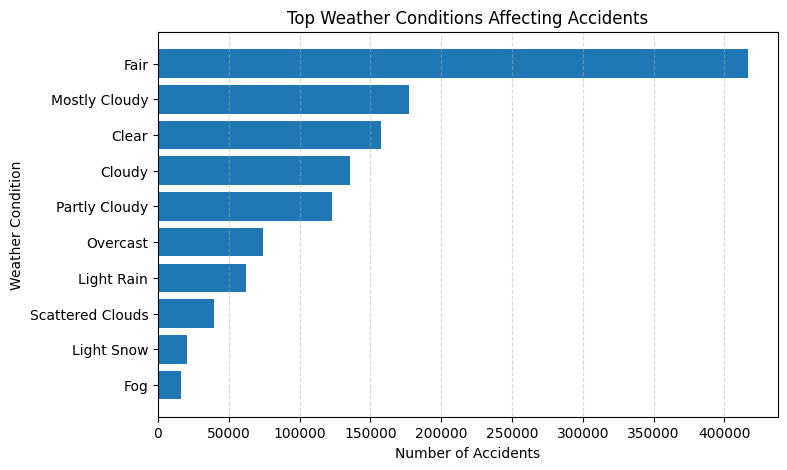

In [ ]:
# Import plotting library
import matplotlib.pyplot as plt

# Set figure size
plt.figure(figsize=(8,5))

# Plot horizontal bar chart of top 10 weather conditions vs accident count
plt.barh(weather_pd["Weather_Condition"], weather_pd["count"])

# Set chart title and axis labels
plt.title("Top Weather Conditions Affecting Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")

# Invert y-axis so highest count appears at the top
plt.gca().invert_yaxis()

# Add vertical dashed gridlines for easier reading
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Display the chart
plt.show()

### Weather Condition Analysis (Table + Visualization)

The analysis of weather conditions reveals that most accidents occur under relatively normal driving conditions rather than extreme weather. The table and corresponding visualization show that **“Fair” weather accounts for the highest number of accidents (34.07%)**, followed by **“Mostly Cloudy” (14.49%)**, **“Clear” (12.89%)**, and **“Cloudy” (11.07%)** conditions.

Moderate conditions such as **“Partly Cloudy” (10.02%)** and **“Overcast” (6.08%)** also contribute significantly to accident counts. In contrast, more adverse conditions like **“Light Rain” (5.06%)**, **“Scattered Clouds” (3.25%)**, **“Light Snow” (1.69%)**, and **“Fog” (1.35%)** account for a much smaller proportion of accidents.

These results suggest that accidents are more frequent during common driving conditions, likely due to higher traffic volumes rather than hazardous weather alone. While severe weather may increase risk per event, it occurs less frequently, leading to fewer total accidents in the dataset.

The visualization reinforces this pattern, with a clear dominance of “Fair” weather conditions and a gradual decline across less common weather types. This highlights the importance of focusing on traffic density and driver behavior even in seemingly safe weather conditions.


###10. Geographic Analysis
This identifies which states have the highest number of accidents and how severity varies by state

In [ ]:
# Display top 10 states with highest number of accidents in descending order
df_sample.groupBy("State").count().orderBy("count", ascending=False).show(10)

# Display accident count broken down by state and severity level to identify high risk states
df_sample.groupBy("State", "Severity").count().orderBy("State", "Severity").show(20)

+-----+------+
|State| count|
+-----+------+
|   CA|290933|
|   FL|136552|
|   TX|106983|
|   SC| 70655|
|   NC| 58077|
|   NY| 58047|
|   VA| 47570|
|   PA| 46684|
|   MN| 32585|
|   IL| 31718|
+-----+------+
only showing top 10 rows
+-----+--------+------+
|State|Severity| count|
+-----+--------+------+
|   AL|       1|   132|
|   AL|       2| 14245|
|   AL|       3|  4238|
|   AL|       4|   315|
|   AR|       1|     3|
|   AR|       2|  2979|
|   AR|       3|   108|
|   AR|       4|   396|
|   AZ|       1|  1332|
|   AZ|       2| 23371|
|   AZ|       3|  3452|
|   AZ|       4|   785|
|   CA|       1|  1844|
|   CA|       2|234589|
|   CA|       3| 52481|
|   CA|       4|  2019|
|   CO|       1|   166|
|   CO|       2|  9070|
|   CO|       3|  4973|
|   CO|       4|  1138|
+-----+--------+------+
only showing top 20 rows


### 11. Infrastructure Analysis
This checks whether road infrastructure features such as junctions, traffic signals, and crossings are related to accident occurrence.

In [ ]:
# Count and display number of accidents at junction vs non-junction locations
df_sample.groupBy("Junction").count().show()

# Count and display number of accidents at traffic signal vs non-traffic signal locations
df_sample.groupBy("Traffic_Signal").count().show()

+--------+-------+
|Junction|  count|
+--------+-------+
|       1| 102758|
|       0|1204591|
+--------+-------+

+--------------+-------+
|Traffic_Signal|  count|
+--------------+-------+
|             1| 209751|
|             0|1097598|
+--------------+-------+



###12. Relationship with Severity
This compares average values of important features across severity levels. It helps understand which features may influence severity.


In [ ]:
# Calculate and display average visibility for each severity level
df_sample.groupBy("Severity").avg("Visibility").orderBy("Severity").show()

# Calculate and display average temperature for each severity level
df_sample.groupBy("Severity").avg("Temperature").orderBy("Severity").show()

# Calculate and display average wind speed for each severity level
df_sample.groupBy("Severity").avg("Wind_Speed").orderBy("Severity").show()


+--------+-----------------+
|Severity|  avg(Visibility)|
+--------+-----------------+
|       1|9.491156944105443|
|       2|9.102429951029041|
|       3| 9.09472628528307|
|       4|9.021363330879764|
+--------+-----------------+

+--------+-----------------+
|Severity| avg(Temperature)|
+--------+-----------------+
|       1|72.91082092588073|
|       2| 61.7061635013101|
|       3| 62.2624731061943|
|       4|58.42880916567987|
+--------+-----------------+

+--------+------------------+
|Severity|   avg(Wind_Speed)|
+--------+------------------+
|       1|7.0549426409567975|
|       2| 7.157130059338765|
|       3| 7.494307344015911|
|       4| 7.132377508240779|
+--------+------------------+



###13. Outlier Detection
This helps identify unrealistic or extreme values that may affect analysis and model performance.

In [ ]:
from pyspark.sql.functions import col  # Import column function for filtering

# Check for unrealistic visibility values below 0 to identify data quality issues
df_sample.filter(col("Visibility") < 0).show(5)

# Check for unrealistic wind speed values above 100 to identify outliers in the dataset
df_sample.filter(col("Wind_Speed") > 100).show(5)

+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+----+-----+------------+-------+---------+----------+-------+---------------------------+--------------+-------+------+-----+----+
|Severity|Start_Time|State|Temperature|Visibility|Wind_Speed|Weather_Condition|Sunrise_Sunset|Junction|Traffic_Signal|Pressure|Hour|label|is_rush_hour|sun_idx|DayOfWeek|is_weekend|is_snow|temp_visibility_interaction|low_visibility|is_rain|is_fog|Month|Year|
+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+----+-----+------------+-------+---------+----------+-------+---------------------------+--------------+-------+------+-----+----+
+--------+----------+-----+-----------+----------+----------+-----------------+--------------+--------+--------------+--------+----+-----+------------+-------+---------+----------+-------+---------------------------+----------

###14. Data Quality Check
This checks missing values and duplicate rows. Data quality checks are important before training the model to avoid errors and unreliable results.

In [ ]:
from pyspark.sql.functions import col, sum  # Import column and sum functions

# Count and display the number of missing values in each column across the entire dataset
df.select([
    sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
]).show()

# Print total number of rows in the dataset
print("Total rows:", df.count())

# Print number of unique rows after removing duplicates
print("Distinct rows:", df.distinct().count())

# Print number of duplicate rows by comparing total vs distinct row count
print("Duplicate rows:", df.count() - df.distinct().count())


+---+------+--------+----------+--------+---------+---------+-------+-------+------------+-----------+------+----+------+-----+-------+-------+--------+------------+-----------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+-------+----+--------+--------+--------+-------+-------+----------+-------+----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
| ID|Source|Severity|Start_Time|End_Time|Start_Lat|Start_Lng|End_Lat|End_Lng|Distance(mi)|Description|Street|City|County|State|Zipcode|Country|Timezone|Airport_Code|Weather_Timestamp|Temperature(F)|Wind_Chill(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Amenity|Bump|Crossing|Give_Way|Junction|No_Exit|Railway|Roundabout|Station|Stop|Traffic_Calming|Traffic_Signal|Turning_Loop|Sunrise_Sunset|Civil_Twilight|Nautical_Twil

## 15. State Severity Risk Index (SSRI)

To identify high-risk geographic regions, a State Severity Risk Index (SSRI) is constructed.
SSRI is defined as the proportion of high-severity accidents (Severity ≥ 3) within each state.

This metric allows comparison across states by normalizing for total accident counts.
Higher SSRI values indicate a greater likelihood of severe accidents.

In [ ]:
from pyspark.sql.functions import col, avg, desc, round

# Step 1: create binary column
df_ssri = df_sample.filter(col("Severity").isNotNull()) \
    .withColumn(
        "high_severity",
        (col("Severity") >= 3).cast("int")
    )

# Step 2: compute SSRI
df_ssri = df_ssri.groupBy("State") \
    .agg(avg("high_severity").alias("SSRI")) \
    .orderBy(desc("SSRI"))

# Step 3: round
df_ssri = df_ssri.withColumn("SSRI", round(col("SSRI"), 3))

# Step 4: show
df_ssri.show(10)

+-----+-----+
|State| SSRI|
+-----+-----+
|   RI|0.472|
|   GA|0.467|
|   KY|0.439|
|   MO|0.407|
|   CO|0.398|
|   SD|0.385|
|   WI|0.382|
|   IL|0.372|
|   IA|0.364|
|   NM|0.357|
+-----+-----+
only showing top 10 rows


### SSRI Insights

The State Severity Risk Index (SSRI) highlights regional differences in accident severity across the United States. States such as Rhode Island and Georgia exhibit higher SSRI values, indicating a larger proportion of severe accidents relative to total incidents.

These variations may be influenced by factors such as road infrastructure, traffic conditions, weather patterns, and driver behavior. Identifying high-risk states is important for prioritizing targeted safety interventions, improving traffic management systems, and allocating resources effectively to reduce accident severity.


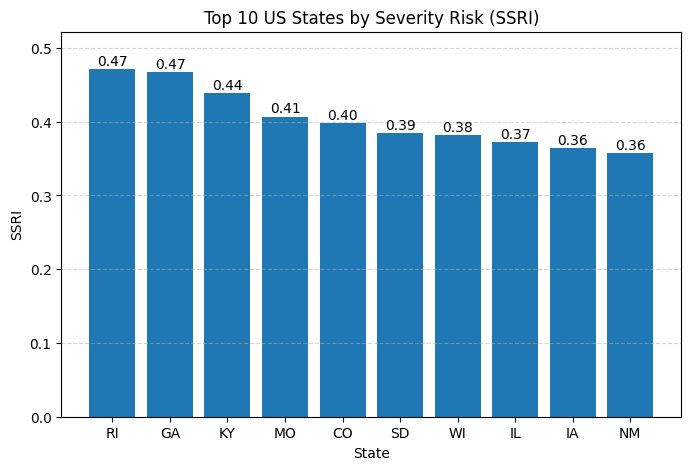

In [ ]:
import matplotlib.pyplot as plt  # Import plotting library

# Select top 10 states by SSRI and convert to Pandas for plotting
top_n = 10
ssri_pd = df_ssri.limit(top_n).toPandas()

# Set figure size
plt.figure(figsize=(8,5))

# Plot bar chart of top 10 states by SSRI value
plt.bar(ssri_pd["State"], ssri_pd["SSRI"])

# Set chart title and axis labels
plt.title("Top 10 US States by Severity Risk (SSRI)")
plt.xlabel("State")
plt.ylabel("SSRI")

# Add SSRI value labels on top of each bar for readability
for i, v in enumerate(ssri_pd["SSRI"]):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

# Set y-axis limit slightly above max value to fit labels and add dashed gridlines
plt.ylim(0, max(ssri_pd["SSRI"]) + 0.05)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the chart
plt.show()

### Train-Test Split

The dataset is split into training and testing sets to evaluate model performance on unseen data.

In [ ]:
from pyspark.ml.feature import VectorAssembler  # Import feature assembler for combining columns into vector

# Define list of all feature columns to be used for model training
features = [
    "Temperature",
    "Visibility",
    "Wind_Speed",
    "Hour",
    "is_rush_hour",
    "sun_idx",
    "is_weekend",
    "Junction",
    "Traffic_Signal",
    "temp_visibility_interaction",
    "low_visibility",
    "is_rain",
    "is_fog",
    "Pressure",
    "is_snow"
]

# Combine all feature columns into a single vector column called "features"
assembler = VectorAssembler(inputCols=features, outputCol="features")

# Apply the assembler and keep only features and label columns for modeling
df_model = assembler.transform(df_sample).select("features", "label")

from pyspark.ml.feature import StandardScaler  # Import scaler for feature normalization

# Standardize features to have zero mean and unit variance for Logistic Regression
# withMean=True → subtract mean, withStd=True → divide by standard deviation
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,
    withStd=True
)

# Display first 5 rows of the model-ready DataFrame to verify output
df_model.show(5)


+--------------------+-----+
|            features|label|
+--------------------+-----+
|(15,[0,1,2,3,4,9,...|    1|
|(15,[0,1,2,3,8,9,...|    1|
|(15,[0,1,2,5,9,13...|    0|
|(15,[0,1,2,3,9,13...|    1|
|(15,[0,1,2,3,9,10...|    1|
+--------------------+-----+
only showing top 5 rows


In [ ]:
# Split first
train_df, test_df = df_model.randomSplit([0.8, 0.2], seed=42)

# Fit scaler ONLY on training data
scaler_model = scaler.fit(train_df)

train_scaled = scaler_model.transform(train_df) \
    .select("scaled_features", "label") \
    .withColumnRenamed("scaled_features", "features")

test_scaled = scaler_model.transform(test_df) \
    .select("scaled_features", "label") \
    .withColumnRenamed("scaled_features", "features")

# For RF only
train_clean = train_df.select("features", "label")
test_clean = test_df.select("features", "label")

# cache AFTER creating final dataframes
train_df = train_df.cache()
test_df = test_df.cache()
train_scaled = train_scaled.cache()
test_scaled = test_scaled.cache()
train_clean = train_clean.cache()
test_clean = test_clean.cache()

train_size = train_df.count()
test_size = test_df.count()

print("Training size:", train_size)
print("Testing size:", test_size)

Training size: 1045676
Testing size: 261673


In [ ]:
from pyspark.sql.functions import col, when  # Import column and conditional functions

# Count majority class (low severity) and minority class (high severity) in training data
rf_majority_count = train_df.filter(col("label") == 0).count()
rf_minority_count = train_df.filter(col("label") == 1).count()

# Calculate total number of training records
rf_total_train = rf_majority_count + rf_minority_count

# Calculate class weights inversely proportional to class frequency
# Higher weight for minority class so model pays more attention to severe accidents
weight_0 = rf_total_train / (2 * rf_majority_count)
weight_1 = rf_total_train / (2 * rf_minority_count)

# Add weight column to training DataFrame based on each record's label
train_rf = train_df.withColumn(
    "weight",
    when(col("label") == 0, weight_0).otherwise(weight_1)
)

# Cache training DataFrame in memory for faster repeated access
train_df = train_df.cache()

# Trigger cache and confirm total number of training records
train_rf.count()

# Print calculated class weights for verification
print("RF Class 0 weight:", weight_0)
print("RF Class 1 weight:", weight_1)

RF Class 0 weight: 0.6368888753540214
RF Class 1 weight: 2.326298881873718


In [ ]:
from pyspark.ml.classification import RandomForestClassifier  # Import Random Forest classifier

# Define Random Forest model with the following configuration:
# labelCol   → target column to predict (severe or not severe)
# featuresCol → input feature vector column
# weightCol  → use class weights to handle class imbalance
# numTrees   → build 30 decision trees and combine their votes
# maxDepth   → each tree can ask up to 8 levels of questions
# maxBins    → number of bins for splitting continuous features
# seed       → fixed random seed for reproducibility
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    weightCol="weight",
    numTrees=30,
    maxDepth=8,
    maxBins=64,
    seed=42
)

# Train the Random Forest model on the training dataset
rf_model = rf.fit(train_rf)


In [ ]:
import pandas as pd  # Import Pandas for creating feature importance table

# Define feature names matching the order used during model training
feature_names = features

# Extract feature importance scores from the trained Random Forest model as an array
importance = rf_model.featureImportances.toArray()

# Create a Pandas DataFrame mapping each feature to its importance score
# Sort in descending order so most important features appear at the top
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

# Display the feature importance table
feature_importance_df

,Feature,Importance
8,Traffic_Signal,0.521121
13,Pressure,0.200607
2,Wind_Speed,0.118326
7,Junction,0.040669
0,Temperature,0.028993
6,is_weekend,0.023574
3,Hour,0.021878
9,temp_visibility_interaction,0.010797
1,Visibility,0.008862
11,is_rain,0.008644


**Observation:**  
The dataset is split into 80% training data and 20% testing data. This ensures that the model is trained on a large portion of the data while retaining a separate subset for unbiased evaluation of performance.

### Train Random Forest Model



A Random Forest Classifier is trained using the training dataset.  
Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and reduce overfitting.

In this step:
- The model is initialized with parameters such as number of trees and depth
- The model is trained using the training dataset (`train_df`)
- The trained model learns patterns between input features and accident severity

### Generate Predictions

The trained Random Forest model is used to make predictions on the test dataset.

In this step:
- The model predicts the class label (`prediction`)
- It also outputs probability scores for each class
- These predictions are used for evaluating model performance

The output includes:
- Actual label (`label`)
- Predicted label (`prediction`)
- Prediction probability (`probability`)

In [ ]:
from pyspark.sql.functions import when, col
from pyspark.ml.functions import vector_to_array

# Generate predictions
predictions = rf_model.transform(test_df)

# Convert vector → array
predictions = predictions.withColumn(
    "prob_array",
    vector_to_array(col("probability"))
)

# Apply threshold
predictions = predictions.withColumn(
    "custom_prediction",
    when(col("prob_array")[1] > 0.5, 1.0).otherwise(0.0)
)

# View results
predictions.select("label", "prediction", "custom_prediction", "prob_array").show(10, truncate=False)

+-----+----------+-----------------+-----------------------------------------+
|label|prediction|custom_prediction|prob_array                               |
+-----+----------+-----------------+-----------------------------------------+
|1    |1.0       |1.0              |[0.363842522140431, 0.636157477859569]   |
|0    |0.0       |0.0              |[0.5735827124344002, 0.42641728756559977]|
|0    |0.0       |0.0              |[0.5657665833554278, 0.4342334166445722] |
|0    |1.0       |1.0              |[0.3391212349449922, 0.6608787650550078] |
|0    |0.0       |0.0              |[0.6187496257878363, 0.3812503742121637] |
|0    |0.0       |0.0              |[0.5600884074040359, 0.4399115925959642] |
|0    |1.0       |1.0              |[0.3481869863740643, 0.6518130136259356] |
|0    |0.0       |0.0              |[0.5618642603619856, 0.43813573963801444]|
|0    |1.0       |1.0              |[0.3786799241529374, 0.6213200758470626] |
|1    |1.0       |1.0              |[0.3786799241529

### Model Evaluation

The performance of the model is evaluated using multiple metrics:

- **AUC (Area Under ROC Curve):** Measures how well the model distinguishes between classes  
- **Accuracy:** Percentage of correct predictions  
- **Precision:** Correct positive predictions out of total predicted positives  
- **Recall:** Correct positive predictions out of total actual positives  
- **F1 Score:** Harmonic mean of precision and recall  

Since the dataset is imbalanced, AUC and F1 Score are more reliable metrics than accuracy alone.

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# AUC
auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = auc_evaluator.evaluate(predictions)

# Accuracy
acc_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="custom_prediction",
    metricName="accuracy"
)
accuracy = acc_evaluator.evaluate(predictions)

# F1 Score
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="custom_prediction",
    metricName="f1"
)
f1 = f1_evaluator.evaluate(predictions)

# Precision
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="custom_prediction",
    metricName="weightedPrecision"
)
precision = precision_evaluator.evaluate(predictions)

# Recall
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="custom_prediction",
    metricName="weightedRecall"
)
recall = recall_evaluator.evaluate(predictions)

print("AUC:", auc)
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

AUC: 0.6439463860055009
Accuracy: 0.5460211791052191
F1 Score: 0.5852102730966487
Precision: 0.7377519582125454
Recall: 0.5460211791052191


### Confusion Matrix

The confusion matrix provides a detailed breakdown of prediction results:

- True Positives (TP): Correctly predicted high severity accidents  
- True Negatives (TN): Correctly predicted low severity accidents  
- False Positives (FP): Incorrectly predicted high severity  
- False Negatives (FN): Missed high severity predictions  

This helps in understanding where the model is making errors.

In [ ]:
# Display confusion matrix by grouping actual labels vs predicted labels and counting each combination
predictions.groupBy("label", "custom_prediction") \
           .count() \
           .orderBy("label", "custom_prediction") \
           .show()

+-----+-----------------+------+
|label|custom_prediction| count|
+-----+-----------------+------+
|    0|              0.0|103837|
|    0|              1.0|102212|
|    1|              0.0| 16582|
|    1|              1.0| 39042|
+-----+-----------------+------+



## Feature Importance

In [ ]:
# Print raw feature importance scores from the trained Random Forest model
print("Feature Importances:")
print(rf_model.featureImportances)

Feature Importances:
(15,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],[0.028992669179267135,0.008861570496066751,0.11832563783808546,0.021878273261548977,0.0011066302914045645,0.006559552114162042,0.023574079120943937,0.040669321828148156,0.5211205518414943,0.010796979866915947,0.0012247447138872011,0.008643524702596007,0.006435201293797462,0.20060665149752174,0.001204611954160278])


### Observation

The Random Forest model successfully captures relationships between features such as weather conditions, visibility, and time-based factors.

Key observations:
- The model performs well due to its ability to handle non-linear relationships  
- AUC and F1 Score provide better insight due to class imbalance  
- Some misclassifications are observed, which may be due to overlapping feature patterns  

Overall, Random Forest is a suitable model for this problem due to its robustness and ability to handle complex datasets.



## Logistic Regression Analysis

To compare Random Forest with a simpler and more interpretable model, we implement Logistic Regression. Since the dataset is imbalanced, we evaluate the baseline model first and then test different imbalance-handling strategies such as downsampling and class weighting.

### Helper Function

In [ ]:
from pyspark.sql.functions import col, when  # Import column and conditional functions
from pyspark.ml.classification import LogisticRegression  # Import Logistic Regression classifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator  # Import evaluator for binary classification
import pandas as pd  # Import Pandas for result table creation

# Define helper function to calculate precision, recall and F1 score for severe accident class
def get_class1_metrics(pred_df, prediction_col="custom_prediction", label_col="label"):

    # Build confusion matrix by grouping actual vs predicted labels
    cm = pred_df.groupBy(label_col, prediction_col).count().collect()

    # Map each label-prediction combination to its count
    counts = {
        (int(row[label_col]), float(row[prediction_col])): row["count"]
        for row in cm
    }

    # Extract True Positives, False Negatives, False Positives and True Negatives
    tp = counts.get((1, 1.0), 0)
    fn = counts.get((1, 0.0), 0)
    fp = counts.get((0, 1.0), 0)
    tn = counts.get((0, 0.0), 0)

    # Calculate precision, recall and F1 score for severe accident class
    precision_1 = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_1 = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_1 = (
        2 * precision_1 * recall_1 / (precision_1 + recall_1)
        if (precision_1 + recall_1) > 0 else 0
    )

    # Return all metrics as a dictionary
    return {
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
        "Precision_Severe": precision_1,
        "Recall_Severe": recall_1,
        "F1_Severe": f1_1
    }

# Define ROC-AUC evaluator to measure overall model discrimination ability
auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

# Define PR-AUC evaluator to measure precision recall tradeoff across all thresholds
pr_auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

### Baseline Logistic Regression

In [ ]:
# Import required functions for threshold sweep analysis
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import when, col
import pandas as pd

# Define function to evaluate model performance across multiple probability thresholds
# instead of using a single arbitrary threshold like 0.35
def threshold_sweep(pred_df, thresholds=None):

    # Use default threshold range from 0.25 to 0.60 if none provided
    if thresholds is None:
        thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

    # Extract probability array from prediction vector column
    pred_probs = pred_df.withColumn(
        "prob_array",
        vector_to_array(col("probability"))
    )

    # Initialize empty list to store metrics for each threshold
    rows = []

    # Loop through each threshold and calculate model performance metrics
    for t in thresholds:

        # Apply current threshold to classify predictions as severe or not severe
        temp = pred_probs.withColumn(
            "threshold_prediction",
            when(col("prob_array")[1] >= t, 1.0).otherwise(0.0)
        )

        # Calculate precision, recall, F1 and confusion matrix values for this threshold
        m = get_class1_metrics(
            temp,
            prediction_col="threshold_prediction",
            label_col="label"
        )

        # Append metrics for current threshold to results list
        rows.append({
            "threshold": t,
            "precision_severe": m["Precision_Severe"],
            "recall_severe": m["Recall_Severe"],
            "f1_severe": m["F1_Severe"],
            "TP": m["TP"],
            "FP": m["FP"],
            "FN": m["FN"],
            "TN": m["TN"]
        })

    # Return all threshold results as a Pandas DataFrame for easy comparison
    return pd.DataFrame(rows)

In [ ]:
# Define baseline Logistic Regression model with L2 regularization and 100 iterations
lr_baseline = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

# Train baseline Logistic Regression model on scaled training data
lr_baseline_model = lr_baseline.fit(train_scaled)

# Generate predictions on scaled test data
lr_baseline_preds = lr_baseline_model.transform(test_scaled)

# Extract probability array from prediction vector for custom thresholding
lr_baseline_preds = lr_baseline_preds.withColumn(
    "prob_array",
    vector_to_array(col("probability"))
)

# Apply custom threshold of 0.35 to classify severe vs non severe accidents
lr_baseline_preds = lr_baseline_preds.withColumn(
    "custom_prediction",
    when(col("prob_array")[1] > 0.35, 1.0).otherwise(0.0)
)

# Display confusion matrix showing actual vs predicted label counts
lr_baseline_preds.groupBy("label", "custom_prediction").count().show()

# Calculate precision, recall and F1 score for severe accident class
lr_baseline_metrics = get_class1_metrics(lr_baseline_preds)

# Calculate ROC-AUC score for baseline model
lr_baseline_auc = auc_eval.evaluate(lr_baseline_preds)

# Calculate PR-AUC score for baseline model
lr_baseline_pr_auc = pr_auc_eval.evaluate(lr_baseline_preds)

+-----+-----------------+------+
|label|custom_prediction| count|
+-----+-----------------+------+
|    1|              0.0| 55476|
|    0|              0.0|205786|
|    1|              1.0|   148|
|    0|              1.0|   263|
+-----+-----------------+------+



### 1:1 Downsampling

In [ ]:
# Separate training data into majority class (low severity) and minority class (high severity)
train_majority = train_clean.filter(col("label") == 0)
train_minority = train_clean.filter(col("label") == 1)

# Count number of records in each class
majority_count = train_majority.count()
minority_count = train_minority.count()

# Calculate fraction needed to downsample majority class to match minority class size
fraction_1to1 = minority_count / majority_count

# Randomly sample majority class rows to achieve 1:1 ratio without replacement
train_majority_down_1to1 = train_majority.sample(
    withReplacement=False,
    fraction=fraction_1to1,
    seed=42
)

# Combine downsampled majority class with full minority class to create 1:1 training set
train_1to1 = train_majority_down_1to1.union(train_minority)

# Display class distribution of 1:1 downsampled training data to verify balance
print("1:1 Downsampled Training Distribution:")
train_1to1.groupBy("label").count().show()

1:1 Downsampled Training Distribution:
+-----+------+
|label| count|
+-----+------+
|    0|225474|
|    1|224751|
+-----+------+



### Train LR with 1:1 Downsampling

In [ ]:
# Define Logistic Regression model for 1:1 downsampled training data
lr_1to1 = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

# Scale the 1:1 downsampled training data using the already fitted scaler model
train_1to1_scaled = scaler_model.transform(train_1to1) \
    .select("scaled_features", "label") \
    .withColumnRenamed("scaled_features", "features")

# Train Logistic Regression model on 1:1 downsampled scaled training data
lr_1to1_model = lr_1to1.fit(train_1to1_scaled)

# Generate predictions on scaled test data
lr_1to1_preds = lr_1to1_model.transform(test_scaled)

# Import required functions for probability extraction and thresholding
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when

# Extract probability array from prediction vector for custom thresholding
lr_1to1_preds = lr_1to1_preds.withColumn(
    "prob_array",
    vector_to_array(col("probability"))
)

# Apply custom threshold of 0.35 to classify severe vs non severe accidents
lr_1to1_preds = lr_1to1_preds.withColumn(
    "custom_prediction",
    when(col("prob_array")[1] > 0.35, 1.0).otherwise(0.0)
)

# Run threshold sweep to evaluate model performance across multiple thresholds
threshold_sweep(lr_1to1_preds)

# Store and print threshold sweep results for comparison
sweep_results = threshold_sweep(lr_1to1_preds)
print(sweep_results)

# Display confusion matrix for 1:1 downsampled Logistic Regression model
print("1:1 Downsampled LR Confusion Matrix:")
lr_1to1_preds.groupBy("label", "custom_prediction").count().orderBy("label", "custom_prediction").show()

# Calculate precision, recall and F1 score for severe accident class
lr_1to1_metrics = get_class1_metrics(lr_1to1_preds)

# Calculate ROC-AUC score for 1:1 downsampled model
lr_1to1_auc = auc_eval.evaluate(lr_1to1_preds)

# Calculate PR-AUC score for 1:1 downsampled model
lr_1to1_pr_auc = pr_auc_eval.evaluate(lr_1to1_preds)

# Print AUC score and display metrics table
print("1:1 LR AUC:", lr_1to1_auc)
lr_1to1_metrics

   threshold  precision_severe  recall_severe  f1_severe     TP      FP  \
0       0.25          0.214326       0.995847   0.352736  55393  203059   
1       0.30          0.229591       0.955109   0.370195  53127  178271   
2       0.35          0.234729       0.922174   0.374207  51295  167234   
3       0.40          0.235866       0.906533   0.374335  50425  163362   
4       0.45          0.239066       0.894758   0.377318  49770  158415   
5       0.50          0.249946       0.794855   0.380304  44213  132677   
6       0.55          0.282435       0.293758   0.287985  16340   41514   
7       0.60          0.323879       0.067129   0.111209   3734    7795   

      FN      TN  
0    231    2990  
1   2497   27778  
2   4329   38815  
3   5199   42687  
4   5854   47634  
5  11411   73372  
6  39284  164535  
7  51890  198254  
1:1 Downsampled LR Confusion Matrix:
+-----+-----------------+------+
|label|custom_prediction| count|
+-----+-----------------+------+
|    0|          

{'TP': 51295,
 'FN': 4329,
 'FP': 167234,
 'TN': 38815,
 'Precision_Severe': 0.2347285714939436,
 'Recall_Severe': 0.9221738817776499,
 'F1_Severe': 0.37420710333281054}

### 2:1 Downsampling

In [ ]:
# Calculate fraction needed to downsample majority class to twice the minority class size
target_majority_count = 2 * minority_count
fraction_2to1 = target_majority_count / majority_count

# Randomly sample majority class rows to achieve 2:1 ratio without replacement
train_majority_down_2to1 = train_majority.sample(
    withReplacement=False,
    fraction=fraction_2to1,
    seed=42
)

# Combine downsampled majority class with full minority class to create 2:1 training set
train_2to1 = train_majority_down_2to1.union(train_minority)

# Display class distribution of 2:1 downsampled training data to verify balance
print("2:1 Downsampled Training Distribution:")
train_2to1.groupBy("label").count().show()

2:1 Downsampled Training Distribution:
+-----+------+
|label| count|
+-----+------+
|    0|450467|
|    1|224751|
+-----+------+



### Train LR with 2:1 Downsampling

In [ ]:
# Define Logistic Regression model for 2:1 downsampled training data
lr_2to1 = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

# Scale the 2:1 downsampled training data using the already fitted scaler model
train_2to1_scaled = scaler_model.transform(train_2to1) \
    .select("scaled_features", "label") \
    .withColumnRenamed("scaled_features", "features")

# Train Logistic Regression model on 2:1 downsampled scaled training data
lr_2to1_model = lr_2to1.fit(train_2to1_scaled)

# Generate predictions on scaled test data
lr_2to1_preds = lr_2to1_model.transform(test_scaled)

# Import required functions for probability extraction and thresholding
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when

# Extract probability array from prediction vector for custom thresholding
lr_2to1_preds = lr_2to1_preds.withColumn(
    "prob_array",
    vector_to_array(col("probability"))
)

# Apply custom threshold of 0.35 to classify severe vs non severe accidents
lr_2to1_preds = lr_2to1_preds.withColumn(
    "custom_prediction",
    when(col("prob_array")[1] > 0.35, 1.0).otherwise(0.0)
)

# Display confusion matrix for 2:1 downsampled Logistic Regression model
print("2:1 Downsampled LR Confusion Matrix:")
lr_2to1_preds.groupBy("label", "custom_prediction").count().orderBy("label", "custom_prediction").show()

# Calculate precision, recall and F1 score for severe accident class
lr_2to1_metrics = get_class1_metrics(lr_2to1_preds)

# Calculate ROC-AUC score for 2:1 downsampled model
lr_2to1_auc = auc_eval.evaluate(lr_2to1_preds)

# Calculate PR-AUC score for 2:1 downsampled model
lr_2to1_pr_auc = pr_auc_eval.evaluate(lr_2to1_preds)

# Print AUC score and display metrics table
print("2:1 LR AUC:", lr_2to1_auc)
lr_2to1_metrics

2:1 Downsampled LR Confusion Matrix:
+-----+-----------------+------+
|label|custom_prediction| count|
+-----+-----------------+------+
|    0|              0.0|102951|
|    0|              1.0|103098|
|    1|              0.0| 19561|
|    1|              1.0| 36063|
+-----+-----------------+------+

2:1 LR AUC: 0.6055016165514542


{'TP': 36063,
 'FN': 19561,
 'FP': 103098,
 'TN': 102951,
 'Precision_Severe': 0.2591458813891823,
 'Recall_Severe': 0.648335250970804,
 'F1_Severe': 0.3702851862309726}

### Class Weighted Logistic Regression

In [ ]:
# Calculate total number of training records
total_train = majority_count + minority_count

# Calculate class weights inversely proportional to class frequency
# Higher weight for minority class so model pays more attention to severe accidents
weight_0 = total_train / (2 * majority_count)
weight_1 = total_train / (2 * minority_count)

# Add class weight column to training DataFrame based on each record's label
train_weighted = train_scaled.withColumn(
    "classWeight",
    when(col("label") == 0, weight_0).otherwise(weight_1)
)

# Print calculated class weights for verification
print("Class weights:")
print("Class 0 weight:", weight_0)
print("Class 1 weight:", weight_1)

# Display label distribution with corresponding class weights to confirm correct assignment
train_weighted.groupBy("label", "classWeight").count().show()

Class weights:
Class 0 weight: 0.6368888753540214
Class 1 weight: 2.326298881873718
+-----+------------------+------+
|label|       classWeight| count|
+-----+------------------+------+
|    0|0.6368888753540214|820925|
|    1| 2.326298881873718|224751|
+-----+------------------+------+



### Train Weighted LR

In [ ]:
# Import conditional and column functions
from pyspark.sql.functions import when, col

# Add class weight column to training DataFrame based on each record's label
train_weighted = train_scaled.withColumn(
    "classWeight",
    when(col("label") == 0, weight_0).otherwise(weight_1)
)

# Define weighted Logistic Regression model using class weights to handle imbalance
lr_weighted = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="classWeight",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

# Train weighted Logistic Regression model on weighted training data
lr_weighted_model = lr_weighted.fit(train_weighted)

# Generate predictions on scaled test data
lr_weighted_preds = lr_weighted_model.transform(test_scaled)

# Import function to extract probability array from prediction vector
from pyspark.ml.functions import vector_to_array

# Extract probability array from prediction vector for custom thresholding
lr_weighted_preds = lr_weighted_preds.withColumn(
    "prob_array",
    vector_to_array(col("probability"))
)

# Apply custom threshold of 0.35 to classify severe vs non severe accidents
lr_weighted_preds = lr_weighted_preds.withColumn(
    "custom_prediction",
    when(col("prob_array")[1] > 0.35, 1.0).otherwise(0.0)
)

# Display confusion matrix for weighted Logistic Regression model
print("Weighted LR Confusion Matrix:")
lr_weighted_preds.groupBy("label", "custom_prediction").count().orderBy("label", "custom_prediction").show()

# Calculate precision, recall and F1 score for severe accident class
lr_weighted_metrics = get_class1_metrics(lr_weighted_preds)

# Calculate ROC-AUC score for weighted Logistic Regression model
lr_weighted_auc = auc_eval.evaluate(lr_weighted_preds)

# Calculate PR-AUC score for weighted Logistic Regression model
lr_weighted_pr_auc = pr_auc_eval.evaluate(lr_weighted_preds)

# Print AUC score and display metrics table
print("Weighted LR AUC:", lr_weighted_auc)
lr_weighted_metrics

Weighted LR Confusion Matrix:
+-----+-----------------+------+
|label|custom_prediction| count|
+-----+-----------------+------+
|    0|              0.0| 38778|
|    0|              1.0|167271|
|    1|              0.0|  4319|
|    1|              1.0| 51305|
+-----+-----------------+------+

Weighted LR AUC: 0.6048352847852081


{'TP': 51305,
 'FN': 4319,
 'FP': 167271,
 'TN': 38778,
 'Precision_Severe': 0.2347238489129639,
 'Recall_Severe': 0.9223536602905221,
 'F1_Severe': 0.3742159008023341}

### RFC 1:1 DownSampling

In [ ]:
# Define Random Forest model trained on 1:1 downsampled balanced training data
rf_1to1 = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    numTrees=30,
    maxDepth=8,
    maxBins=64,
    minInstancesPerNode=5,
    seed=42
)

# Train Random Forest model on 1:1 downsampled training data
rf_1to1_model = rf_1to1.fit(train_1to1)

# Generate predictions on test data
rf_1to1_preds = rf_1to1_model.transform(test_df)

# Import required functions for probability extraction and thresholding
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col, when

# Extract probability array from prediction vector for custom thresholding
rf_1to1_preds = rf_1to1_preds.withColumn(
    "prob_array",
    vector_to_array(col("probability"))
)

# Apply threshold of 0.5 to classify severe vs non severe accidents
rf_1to1_preds = rf_1to1_preds.withColumn(
    "custom_prediction",
    when(col("prob_array")[1] > 0.5, 1.0).otherwise(0.0)
)

# Display confusion matrix for RF 1:1 downsampled model
rf_1to1_preds.groupBy("label", "custom_prediction").count().orderBy("label", "custom_prediction").show()

# Calculate precision, recall and F1 score for severe accident class
rf_1to1_metrics = get_class1_metrics(rf_1to1_preds)

# Calculate ROC-AUC score for RF 1:1 downsampled model
rf_1to1_auc = auc_eval.evaluate(rf_1to1_preds)

# Calculate PR-AUC score for RF 1:1 downsampled model
rf_1to1_pr_auc = pr_auc_eval.evaluate(rf_1to1_preds)

# Print AUC score and display metrics table
print("RF 1:1 AUC:", rf_1to1_auc)
rf_1to1_metrics

+-----+-----------------+------+
|label|custom_prediction| count|
+-----+-----------------+------+
|    0|              0.0|114307|
|    0|              1.0| 91742|
|    1|              0.0| 19656|
|    1|              1.0| 35968|
+-----+-----------------+------+

RF 1:1 AUC: 0.6452186646045956


{'TP': 35968,
 'FN': 19656,
 'FP': 91742,
 'TN': 114307,
 'Precision_Severe': 0.2816380862892491,
 'Recall_Severe': 0.6466273550985187,
 'F1_Severe': 0.3923767549936182}

## Get RFC metrics from existing RFC predictions

In [ ]:
# Calculate precision, recall and F1 score for severe accident class using RF base model predictions
rfc_metrics = get_class1_metrics(
    predictions,
    prediction_col="custom_prediction",
    label_col="label"
)

# Store ROC-AUC score for Random Forest base model
rfc_auc = auc

# Calculate PR-AUC score for Random Forest base model
rf_pr_auc = pr_auc_eval.evaluate(predictions)

# Print AUC score and display full metrics table for Random Forest base model
print("Random Forest Metrics:")
print("RFC AUC:", rfc_auc)
rfc_metrics

Random Forest Metrics:
RFC AUC: 0.6439463860055009


{'TP': 39042,
 'FN': 16582,
 'FP': 102212,
 'TN': 103837,
 'Precision_Severe': 0.2763957126877823,
 'Recall_Severe': 0.701891269955415,
 'F1_Severe': 0.3966110992594398}

## Final comparison table

In [ ]:
# Build final comparison table summarizing performance metrics for all six models
comparison_df = pd.DataFrame([
    {
        # Random Forest base model with class weighting
        "Model": "Random Forest",
        "ROC_AUC": auc,
        "PR_AUC": rf_pr_auc,
        "Precision_Severe": rfc_metrics["Precision_Severe"],
        "Recall_Severe": rfc_metrics["Recall_Severe"],
        "F1_Severe": rfc_metrics["F1_Severe"],
        "Notes": "Nonlinear model"
    },
    {
        # Random Forest trained on 1:1 downsampled balanced data
        "Model": "Random Forest 1:1 Downsampling",
        "ROC_AUC": rf_1to1_auc,
        "PR_AUC": rf_1to1_pr_auc,
        "Precision_Severe": rf_1to1_metrics["Precision_Severe"],
        "Recall_Severe": rf_1to1_metrics["Recall_Severe"],
        "F1_Severe": rf_1to1_metrics["F1_Severe"],
        "Notes": "RFC trained on balanced data"
    },
    {
        # Baseline Logistic Regression without any imbalance handling
        "Model": "Baseline LR",
        "ROC_AUC": lr_baseline_auc,
        "PR_AUC": lr_baseline_pr_auc,
        "Precision_Severe": lr_baseline_metrics["Precision_Severe"],
        "Recall_Severe": lr_baseline_metrics["Recall_Severe"],
        "F1_Severe": lr_baseline_metrics["F1_Severe"],
        "Notes": "Affected by class imbalance"
    },
    {
        # Logistic Regression trained on 1:1 downsampled data for best recall
        "Model": "LR 1:1 Downsampling",
        "ROC_AUC": lr_1to1_auc,
        "PR_AUC": lr_1to1_pr_auc,
        "Precision_Severe": lr_1to1_metrics["Precision_Severe"],
        "Recall_Severe": lr_1to1_metrics["Recall_Severe"],
        "F1_Severe": lr_1to1_metrics["F1_Severe"],
        "Notes": "Best recall-focused LR model"
    },
    {
        # Logistic Regression trained on 2:1 downsampled data for conservative tradeoff
        "Model": "LR 2:1 Downsampling",
        "ROC_AUC": lr_2to1_auc,
        "PR_AUC": lr_2to1_pr_auc,
        "Precision_Severe": lr_2to1_metrics["Precision_Severe"],
        "Recall_Severe": lr_2to1_metrics["Recall_Severe"],
        "F1_Severe": lr_2to1_metrics["F1_Severe"],
        "Notes": "More conservative LR model"
    },
    {
        # Weighted Logistic Regression handling imbalance without removing any data
        "Model": "Weighted LR",
        "ROC_AUC": lr_weighted_auc,
        "PR_AUC": lr_weighted_pr_auc,
        "Precision_Severe": lr_weighted_metrics["Precision_Severe"],
        "Recall_Severe": lr_weighted_metrics["Recall_Severe"],
        "F1_Severe": lr_weighted_metrics["F1_Severe"],
        "Notes": "Handles imbalance without data loss"
    }
])

# Display final model comparison table
comparison_df

,Model,ROC_AUC,PR_AUC,Precision_Severe,Recall_Severe,F1_Severe,Notes
0,Random Forest,0.643946,0.316657,0.276396,0.701891,0.396611,Nonlinear model
1,Random Forest 1:1 Downsampling,0.645219,0.318352,0.281638,0.646627,0.392377,RFC trained on balanced data
2,Baseline LR,0.605983,0.274011,0.360097,0.002661,0.005282,Affected by class imbalance
3,LR 1:1 Downsampling,0.604973,0.272539,0.234729,0.922174,0.374207,Best recall-focused LR model
4,LR 2:1 Downsampling,0.605502,0.273362,0.259146,0.648335,0.370285,More conservative LR model
5,Weighted LR,0.604835,0.272547,0.234724,0.922354,0.374216,Handles imbalance without data loss


## Model Comparison Visualization

The following visualization compares severe-class precision, recall, and F1-score across the final models.

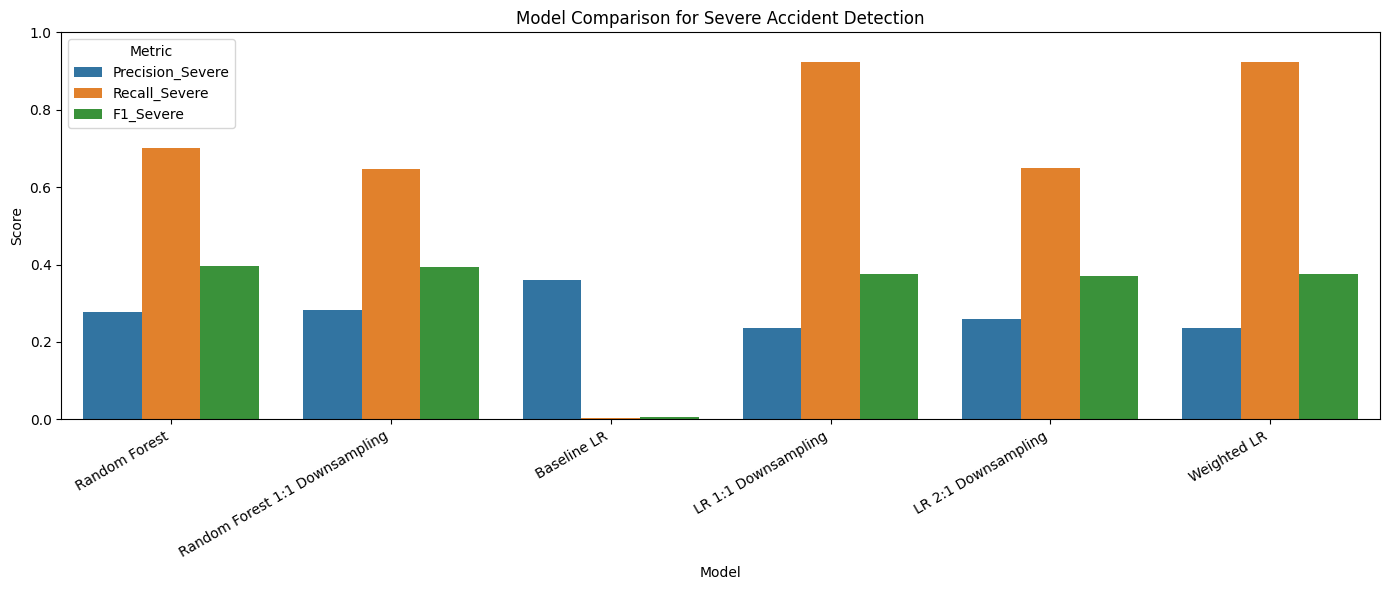

In [ ]:
# Import plotting and visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Select only model name and severe accident metrics for plotting
comparison_plot_df = comparison_df[[
    "Model",
    "Precision_Severe",
    "Recall_Severe",
    "F1_Severe"
]].copy()

# Reshape DataFrame from wide to long format for grouped bar chart plotting
comparison_long = comparison_plot_df.melt(
    id_vars="Model",
    value_vars=["Precision_Severe", "Recall_Severe", "F1_Severe"],
    var_name="Metric",
    value_name="Score"
)

# Set figure size
plt.figure(figsize=(14, 6))

# Plot grouped bar chart comparing precision, recall and F1 across all models
sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

# Set chart title and axis labels
plt.title("Model Comparison for Severe Accident Detection")
plt.xlabel("Model")
plt.ylabel("Score")

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha="right")

# Set y-axis range from 0 to 1 and add metric legend
plt.ylim(0, 1)
plt.legend(title="Metric")

# Adjust layout and display chart
plt.tight_layout()
plt.show()

## Logistic Regression and Random Forest Comparison

The baseline Logistic Regression model was affected by class imbalance and tended to predict low-severity accidents more often. To address this, we tested multiple imbalance-handling strategies: 1:1 downsampling, 2:1 downsampling, and class weighting.

The 1:1 downsampling approach improved recall for high-severity accidents the most, making it useful for the risk-modeling objective of this project. The 2:1 downsampling approach reduced false positives but missed more severe accidents. Class weighting preserved the full training dataset, but in our results it produced more false positives than the 1:1 downsampling approach.

Random Forest was used as a nonlinear comparison model because it can capture more complex relationships among environmental, temporal, and road-infrastructure features. Logistic Regression provides interpretability, while Random Forest provides a stronger nonlinear benchmark.

## Model Interpretation

The models highlight the importance of environmental and road-related factors in determining accident severity. Features such as traffic signals, visibility, and weather conditions (rain and fog) were among the most influential in predicting high-severity accidents.

Random Forest, being a nonlinear model, captures complex interactions between these variables. For example, the combined effect of low visibility and adverse weather conditions significantly increases the likelihood of severe accidents. Logistic Regression, on the other hand, models linear relationships and helps identify the direction of influence of individual features.

Overall, the results suggest that severe accidents are more likely under poor visibility, unfavorable weather conditions, and at locations with traffic control infrastructure, indicating higher-risk driving environments.

## Final Conclusion

In this project, we analyzed large-scale U.S. traffic accident data to model and predict accident severity using Logistic Regression and Random Forest.

The baseline Logistic Regression model was strongly affected by class imbalance and failed to detect high-severity accidents effectively. To address this, we applied imbalance-handling techniques such as 1:1 downsampling, 2:1 downsampling, and class weighting.

Logistic Regression with 1:1 downsampling achieved the highest recall for severe accidents, making it effective for identifying high-risk cases. However, it also produced a large number of false positives, resulting in lower precision.

Random Forest provided the best overall performance, with higher ROC-AUC, PR-AUC, and a better balance between precision and recall. It captured complex relationships between environmental, temporal, and infrastructure-related features, leading to more reliable predictions.

The model comparison visualization highlights the tradeoff between severe-class recall and precision, showing that Logistic Regression variants are more recall-focused, while Random Forest provides a stronger overall balance.

Therefore, Random Forest is selected as the best overall model for this project, while Logistic Regression serves as an interpretable baseline and a recall-focused alternative for risk-sensitive applications.